## 1. Import Required Libraries

In [43]:
#pip install wordcloud


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

## 2. Load the Dataset

In [45]:
df = pd.read_excel("drugsCom_raw.xlsx")
df.head()


,Unnamed: 0,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37


## 3. Dataset Shape and Structure

In [46]:
df.shape


(161297, 7)

In [47]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Unnamed: 0   161297 non-null  int64         
 1   drugName     161297 non-null  object        
 2   condition    160398 non-null  object        
 3   review       161297 non-null  object        
 4   rating       161297 non-null  int64         
 5   date         161297 non-null  datetime64[ns]
 6   usefulCount  161297 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 8.6+ MB


## 4. Column Overview

In [48]:
df.columns


Index(['Unnamed: 0', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount'],
      dtype='object')

## 5. Handling Missing Values

In [49]:
df.isnull().sum()


Unnamed: 0       0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

In [50]:
df = df.dropna(subset=["review", "condition"])
df.isnull().sum()


Unnamed: 0     0
drugName       0
condition      0
review         0
rating         0
date           0
usefulCount    0
dtype: int64

## 6. Filtering Required Conditions

In [51]:
target_conditions = [
    "Depression",
    "High Blood Pressure",
    "Diabetes, Type 2"
]

df = df[df["condition"].isin(target_conditions)]

In [52]:
df["condition"].value_counts()


condition
Depression             9069
Diabetes, Type 2       2554
High Blood Pressure    2321
Name: count, dtype: int64

## 7. Distribution of Conditions (Target Variable)

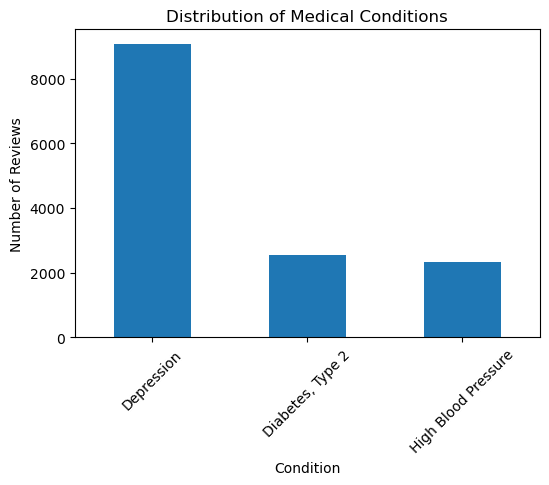

In [53]:
plt.figure(figsize=(6,4))
df["condition"].value_counts().plot(kind="bar")
plt.title("Distribution of Medical Conditions")
plt.xlabel("Condition")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.show()


## 8. Review Length Analysis

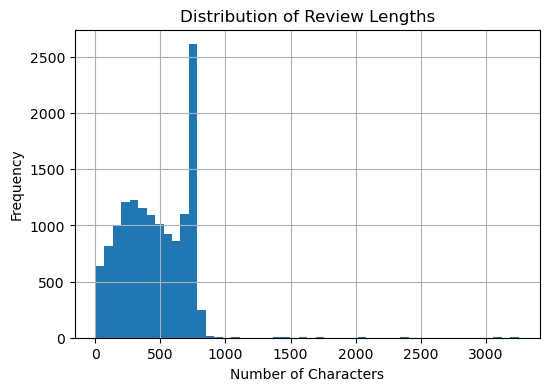

In [54]:
df["review_length"] = df["review"].apply(len)

plt.figure(figsize=(6,4))
df["review_length"].hist(bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()


## 9. Text Cleaning (Preprocessing for NLP)

In [55]:
nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 10. Rating Distribution 

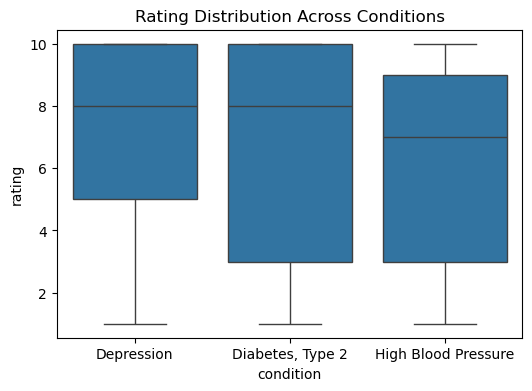

In [56]:
plt.figure(figsize=(6,4))
sns.boxplot(x="condition", y="rating", data=df)
plt.title("Rating Distribution Across Conditions")
plt.show()


## 11. Word Cloud for Each Condition

### Depression

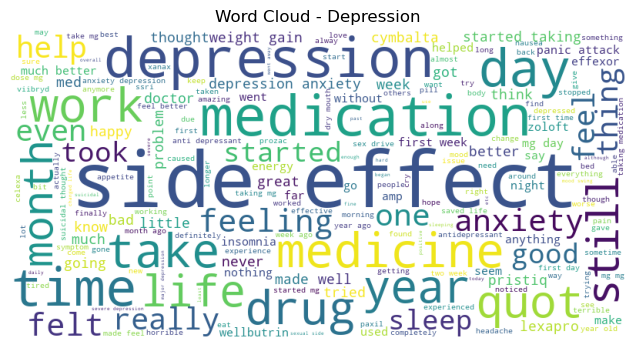

In [57]:
text = " ".join(df[df["condition"]=="Depression"]["clean_review"])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(8,4))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - Depression")
plt.show()


### High Blood Pressure

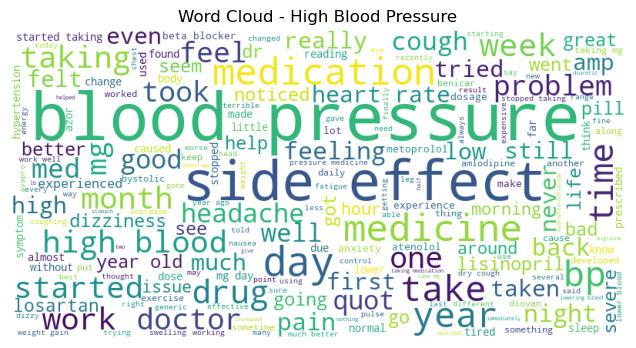

In [58]:
text = " ".join(df[df["condition"]=="High Blood Pressure"]["clean_review"])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(8,4))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - High Blood Pressure")
plt.show()


### Diabetes, Type 2

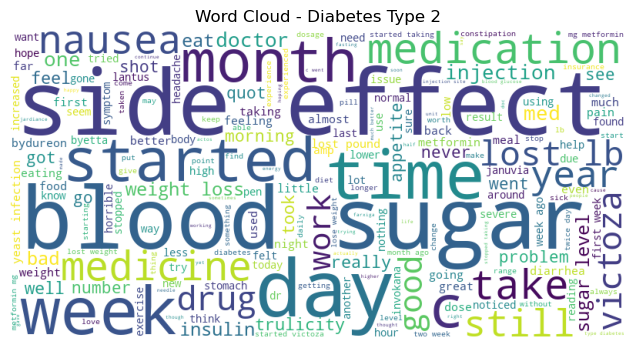

In [59]:
text = " ".join(df[df["condition"]=="Diabetes, Type 2"]["clean_review"])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(8,4))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud - Diabetes Type 2")
plt.show()


## Feature Engineering & Text Vectorization

### 1. Select Input and Target Variables

In [60]:
X = df["clean_review"]
y = df["condition"]


### 2. Train–Test Split

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [62]:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))


Train distribution:
condition
Depression             0.650381
Diabetes, Type 2       0.183147
High Blood Pressure    0.166472
Name: proportion, dtype: float64

Test distribution:
condition
Depression             0.650412
Diabetes, Type 2       0.183220
High Blood Pressure    0.166368
Name: proportion, dtype: float64


### 3. TF-IDF Vectorization

### Initialize TF-IDF Vectorizer

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    stop_words='english'
)



### 4. Fit and Transform Text Data

In [64]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


### 5. Feature Matrix Shape

In [65]:
X_train_tfidf.shape, X_test_tfidf.shape


((11155, 5000), (2789, 5000))

### 6. Understanding TF-IDF Features 

In [66]:
feature_names = tfidf.get_feature_names_out() #These are the words and word combinations used by the model to learn patterns across different conditions.
feature_names[:20]


array(['abdomen', 'abdominal', 'abdominal pain', 'abilify', 'abilify mg',
       'abilify month', 'abilify year', 'ability', 'able', 'able control',
       'able cope', 'able deal', 'able eat', 'able focus',
       'able function', 'able handle', 'able live', 'able lose',
       'able sleep', 'able stop'], dtype=object)

### 7. Label Encoding

In [67]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [68]:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Encoding Mapping:")
print(label_mapping)

Label Encoding Mapping:
{'Depression': np.int64(0), 'Diabetes, Type 2': np.int64(1), 'High Blood Pressure': np.int64(2)}


### Model Building

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# Dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_tfidf, y_train_enc)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test_enc, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")


Logistic Regression Accuracy: 0.9487
Naive Bayes Accuracy: 0.9426
Linear SVM Accuracy: 0.9609
Random Forest Accuracy: 0.9516
Gradient Boosting Accuracy: 0.9204


In [70]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Train model
model = LinearSVC()
model.fit(X_train_tfidf, y_train_enc)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [71]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print("Precision:", precision_score(y_test_enc, y_pred, average='weighted'))
print("Recall:", recall_score(y_test_enc, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test_enc, y_pred, average='weighted'))

print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Accuracy: 0.9609178917174614
Precision: 0.960717079781063
Recall: 0.9609178917174614
F1 Score: 0.9604727799485954
                     precision    recall  f1-score   support

         Depression       0.97      0.99      0.98      1814
   Diabetes, Type 2       0.95      0.95      0.95       511
High Blood Pressure       0.95      0.87      0.91       464

           accuracy                           0.96      2789
          macro avg       0.96      0.94      0.95      2789
       weighted avg       0.96      0.96      0.96      2789



In [72]:
# df must contain: condition, drugName, rating

drug_stats = (
    df.groupby(['condition', 'drugName'])
      .agg(
          avg_rating=('rating', 'mean'),
          review_count=('rating', 'count')
      )
      .reset_index()
)

In [73]:
# Global average rating
C = drug_stats['avg_rating'].mean()

# Confidence factor (tunable)
m = 5  

drug_stats['bayesian_score'] = (
    (drug_stats['review_count'] * drug_stats['avg_rating'] + m * C) /
    (drug_stats['review_count'] + m)
)


In [74]:
def recommend_best_drug(condition, top_n=3):
    filtered = drug_stats[drug_stats['condition'] == condition]

    if filtered.empty:
        return None

    return (
        filtered
        .sort_values(by='bayesian_score', ascending=False)
        .head(top_n)
    )


In [75]:
def predict_condition_and_recommend_drug(review_text):
    # Clean input review
    cleaned = clean_text(review_text)

    # Vectorize
    vec = tfidf.transform([cleaned])

    # Predict encoded label
    label = model.predict(vec)[0]

    # Decode condition
    condition = le.inverse_transform([label])[0]

    # Get drug recommendations
    drugs = recommend_best_drug(condition)

    return condition, drugs


In [77]:
import pickle

pickle.dump(model, open("condition_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))
pickle.dump(drug_stats, open("drug_stats.pkl", "wb"))
